# Dataset Trainability Check — GaitCNN Baseline

**Thesis:** Code Division Modulation Layers Against Forgetting and Inference in Continual Gait Identification  
**Reference:** Milani, S. — University of Padova

---

## Purpose

Before committing to any continual learning strategy, this notebook answers a fundamental question:

> **How well can a standard CNN learn each dataset when given access to all subjects at once (no CL constraints)?**

This is the **upper-bound baseline**: a single GaitCNN trained on a global train/val/test split of each dataset, with no task boundaries, no forgetting, no continual learning overhead.

### Three datasets evaluated

| Dataset | Subjects | Window | Channels | Task |
|---------|----------|--------|----------|------|
| **Gait Dataset 1** | 118 | 128 samples | 6 (acc+gyr) | Subject identification |
| **UCI HAR** | 30 | 128 samples | 6 (acc+gyr) | Subject identification |
| **WISDM** | 51 | 200 samples | 6 (phone acc+gyr) | Subject identification (walking only) |

---

## 0. Imports

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}  |  PyTorch: {torch.__version__}')

Device: mps  |  PyTorch: 2.8.0


## 1. Configuration

In [10]:
# ── Dataset paths ────────────────────────────────────────────────────────────
GAIT_TRAIN_DIR  = '../Data/Dataset_1/train'
GAIT_TEST_DIR   = '../Data/Dataset_1/test'
UCIHAR_DATA_DIR = '../Data/UCI HAR Dataset'
WISDM_DATA_DIR  = '../Data/wisdm-dataset'

# ── Shared training hyperparameters ──────────────────────────────────────────
VAL_SPLIT    = 0.15      # fraction of training data held out as validation
TEST_SPLIT   = 0.15      # only for datasets with no predefined test split
RANDOM_SEED  = 27
BATCH_SIZE   = 64
EMBED_DIM    = 128
EPOCHS       = 100       # 100 = fast | 400 = paper-accurate
LR_INIT      = 1e-3
LR_DECAY     = 0.98

# ── Dataset-specific parameters ───────────────────────────────────────────────
DATASETS = {
    'Gait Dataset 1': {
        'n_channels': 6, 'window_size': 128, 'n_classes': 118,
        'color': '#1A5276', 'marker': 'o',
    },
    'UCI HAR': {
        'n_channels': 6, 'window_size': 128, 'n_classes': 30,
        'color': '#0E6655', 'marker': 's',
    },
    'WISDM': {
        'n_channels': 6, 'window_size': 200, 'n_classes': 51,
        'color': '#7D3C98', 'marker': '^',
    },
}

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('Configuration set.')
for name, cfg in DATASETS.items():
    chance = 100 / cfg['n_classes']
    print(f'  {name:<20}: {cfg["n_classes"]:>3} subjects | '
          f'win={cfg["window_size"]} | ch={cfg["n_channels"]} | '
          f'chance={chance:.1f}%')

Configuration set.
  Gait Dataset 1      : 118 subjects | win=128 | ch=6 | chance=0.8%
  UCI HAR             :  30 subjects | win=128 | ch=6 | chance=3.3%
  WISDM               :  51 subjects | win=200 | ch=6 | chance=2.0%


## 2. Shared Model — GaitCNN

The exact same architecture used in all Phase 11–16 experiments:
4 × ConvBlock → Linear embedding → Linear classifier.
Parameterised by `(n_channels, window_size, n_classes)` so it adapts to all three datasets.

In [11]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, pool=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size,
                      padding=kernel_size // 2),
            nn.ReLU(), nn.MaxPool1d(pool),
        )
    def forward(self, x): return self.block(x)


class GaitCNN(nn.Module):
    """Baseline CNN backbone — Zou et al. 2020 / Milani 2024 (Fig. 2)."""
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128, window_size=128):
        super().__init__()
        self.embed_dim = embed_dim
        self.feature_extractor = nn.Sequential(
            ConvBlock(n_channels, 32), ConvBlock(32, 64),
            ConvBlock(64, 128),        ConvBlock(128, 128), nn.Flatten(),
        )
        flat = self.feature_extractor(
            torch.zeros(1, n_channels, window_size)).shape[1]
        self.embedding  = nn.Linear(flat, embed_dim)
        self.classifier = nn.Linear(embed_dim, n_classes)
        self._flat = flat

    def embed(self, x): return self.embedding(self.feature_extractor(x))
    def forward(self, x): return self.classifier(self.embed(x))
    def param_count(self): return sum(p.numel() for p in self.parameters())


# Sanity check — print flat size for each dataset
for dname, cfg in DATASETS.items():
    m = GaitCNN(cfg['n_channels'], cfg['n_classes'], EMBED_DIM, cfg['window_size'])
    print(f'{dname:<20}: flat={m._flat:>5}  total params={m.param_count():>10,}')
    del m

Gait Dataset 1      : flat= 1024  total params=   227,222
UCI HAR             : flat= 1024  total params=   215,870
WISDM               : flat= 1536  total params=   284,115


## 3. Training & Evaluation Utilities

In [12]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        correct += (model(X_b).argmax(1) == y_b).sum().item()
        total   += len(y_b)
    return correct / total if total > 0 else 0.0


def train_model(model, train_ds, val_ds, test_ds,
                device=DEVICE, epochs=EPOCHS, lr=LR_INIT, decay=LR_DECAY,
                batch_size=BATCH_SIZE, verbose=True):
    """
    Standard training loop with exponential LR decay.
    Returns history dict with train_acc, val_acc, and final test_acc.
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=decay)
    criterion = nn.CrossEntropyLoss()
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=256)
    test_loader  = DataLoader(test_ds,  batch_size=256)

    history = {'train_acc': [], 'val_acc': [], 'epoch': []}
    best_val, best_state = 0.0, None

    for epoch in range(1, epochs + 1):
        model.train()
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            criterion(model(X_b), y_b).backward()
            optimizer.step()
        scheduler.step()

        if epoch % max(1, epochs // 20) == 0 or epoch == 1 or epoch == epochs:
            tr_acc  = evaluate(model, train_loader, device)
            val_acc = evaluate(model, val_loader,   device)
            history['train_acc'].append(tr_acc * 100)
            history['val_acc'].append(val_acc * 100)
            history['epoch'].append(epoch)
            if val_acc > best_val:
                best_val   = val_acc
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            if verbose and (epoch % max(1, epochs // 5) == 0 or epoch == 1):
                print(f'  Epoch {epoch:>4}/{epochs}  '
                      f'train={tr_acc*100:5.1f}%  val={val_acc*100:5.1f}%')

    # Restore best checkpoint and evaluate on test
    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    test_acc = evaluate(model, test_loader, device)
    history['test_acc']  = test_acc * 100
    history['best_val']  = best_val * 100
    return history


print('Training utilities defined.')

Training utilities defined.


## 4. Dataset 1 — Gait (118 subjects)

**Structure:** pre-split `train/` and `test/` directories, 6 × 128 inertial windows.  
Subjects are already disjoint between splits (subject identification task).  
Val set carved from the training split.

In [13]:
def load_gait(train_dir, test_dir, val_split=VAL_SPLIT, seed=RANDOM_SEED):
    axes = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']
    def _load(d, prefix):
        signals = [np.loadtxt(f'{d}/Inertial_Signals/{prefix}_{a}.txt') for a in axes]
        X = np.stack(signals, axis=1).astype(np.float32)
        y = np.loadtxt(f'{d}/y_{prefix}.txt', dtype=int)
        return X, y

    X_tr, y_tr = _load(train_dir, 'train')
    X_te, y_te = _load(test_dir,  'test')

    # Normalise (fit on train only)
    mu  = X_tr.mean(axis=(0, 2), keepdims=True)
    std = X_tr.std( axis=(0, 2), keepdims=True) + 1e-8
    X_tr = (X_tr - mu) / std
    X_te = (X_te - mu) / std

    # 0-index labels
    all_lbls   = np.sort(np.unique(np.concatenate([y_tr, y_te])))
    lbl2idx    = {l: i for i, l in enumerate(all_lbls)}
    y_tr_idx   = np.array([lbl2idx[l] for l in y_tr])
    y_te_idx   = np.array([lbl2idx[l] for l in y_te])

    X_tr_t = torch.tensor(X_tr); y_tr_t = torch.tensor(y_tr_idx, dtype=torch.long)
    full_ds = TensorDataset(X_tr_t, y_tr_t)
    n_val   = max(1, int(len(full_ds) * val_split))
    rng     = torch.Generator().manual_seed(seed)
    train_ds, val_ds = random_split(full_ds, [len(full_ds) - n_val, n_val], generator=rng)
    test_ds  = TensorDataset(torch.tensor(X_te), torch.tensor(y_te_idx, dtype=torch.long))

    print(f'Gait Dataset 1:  train={len(train_ds):>5}  val={n_val:>4}  test={len(test_ds):>5}')
    print(f'  X_train: {X_tr.shape}  X_test: {X_te.shape}')
    print(f'  Subjects: {len(all_lbls)}  |  Chance: {100/len(all_lbls):.2f}%')
    return train_ds, val_ds, test_ds, len(all_lbls)


gait_train, gait_val, gait_test, gait_n_classes = load_gait(GAIT_TRAIN_DIR, GAIT_TEST_DIR)

Gait Dataset 1:  train=28139  val=4965  test= 3740
  X_train: (33104, 6, 128)  X_test: (3740, 6, 128)
  Subjects: 118  |  Chance: 0.85%


In [14]:
torch.manual_seed(RANDOM_SEED)
cfg = DATASETS['Gait Dataset 1']
model_gait = GaitCNN(cfg['n_channels'], gait_n_classes, EMBED_DIM, cfg['window_size']).to(DEVICE)
print(f'Training GaitCNN on Gait Dataset 1  ({model_gait.param_count():,} params)...')
hist_gait = train_model(model_gait, gait_train, gait_val, gait_test)
print(f'\n  ✓ Test accuracy:    {hist_gait["test_acc"]:.2f}%')
print(f'    Best val accuracy: {hist_gait["best_val"]:.2f}%')
print(f'    Chance level:      {100/gait_n_classes:.2f}%')

Training GaitCNN on Gait Dataset 1  (227,222 params)...
  Epoch    1/100  train= 91.3%  val= 90.6%
  Epoch   20/100  train= 99.7%  val= 97.5%
  Epoch   40/100  train= 99.6%  val= 97.4%
  Epoch   60/100  train=100.0%  val= 97.9%
  Epoch   80/100  train=100.0%  val= 98.1%
  Epoch  100/100  train=100.0%  val= 98.1%

  ✓ Test accuracy:    92.14%
    Best val accuracy: 98.35%
    Chance level:      0.85%


## 5. UCI HAR — Subject Identification (30 subjects)

**Structure:** UCI HAR splits by *subject* (21 train / 9 test), not randomly.  
We merge both splits first so every subject has windows in both train and test,  
then re-split per-subject (85% train, 15% test).

**Walking-only filter:** Activities 1–3 (WALKING, WALKING\_UPSTAIRS, WALKING\_DOWNSTAIRS) are retained;  
static activities (SITTING=4, STANDING=5, LAYING=6) are discarded to match the gait-identification focus.


In [15]:
def load_ucihar(data_dir, val_split=VAL_SPLIT, test_split=0.15, seed=RANDOM_SEED):
    axes = ['total_acc_x', 'total_acc_y', 'total_acc_z',
            'body_gyro_x', 'body_gyro_y', 'body_gyro_z']
    # UCI HAR activity labels (1-indexed):
    # 1=WALKING  2=WALKING_UPSTAIRS  3=WALKING_DOWNSTAIRS
    # 4=SITTING  5=STANDING  6=LAYING
    WALKING_LABELS = {1, 2, 3}

    def _load_split(prefix):
        sigs = [np.loadtxt(f'{data_dir}/{prefix}/Inertial Signals/{a}_{prefix}.txt')
                for a in axes]
        X    = np.stack(sigs, axis=1).astype(np.float32)
        subj = np.loadtxt(f'{data_dir}/{prefix}/subject_{prefix}.txt', dtype=int)
        act  = np.loadtxt(f'{data_dir}/{prefix}/y_{prefix}.txt',       dtype=int)
        return X, subj, act

    X_a, s_a, act_a = _load_split('train')
    X_b, s_b, act_b = _load_split('test')
    X_all    = np.concatenate([X_a, X_b], axis=0)   # merge
    subj_all = np.concatenate([s_a, s_b], axis=0)
    act_all  = np.concatenate([act_a, act_b], axis=0)

    print(f'UCI HAR merged: {X_all.shape}  |  subjects: {np.unique(subj_all)}')

    # Keep only walking activities (1=WALKING, 2=WALKING_UPSTAIRS, 3=WALKING_DOWNSTAIRS)
    mask     = np.isin(act_all, list(WALKING_LABELS))
    X_all    = X_all[mask]
    subj_all = subj_all[mask]
    print(f'UCI HAR walking-only (labels 1-3): {X_all.shape}  '
          f'|  retained {mask.sum()} / {len(mask)} windows '
          f'({100 * mask.mean():.1f}%)')

    # Per-subject split: each subject -> ~85% train+val, ~15% test
    rng_np = np.random.default_rng(seed)
    tr_idx, te_idx = [], []
    for s in np.sort(np.unique(subj_all)):
        idx = np.where(subj_all == s)[0]
        rng_np.shuffle(idx)
        cut = max(1, int(len(idx) * (1.0 - test_split)))
        tr_idx.extend(idx[:cut].tolist())
        te_idx.extend(idx[cut:].tolist())
    tr_idx, te_idx = np.array(tr_idx), np.array(te_idx)

    X_tr, X_te = X_all[tr_idx], X_all[te_idx]
    y_tr, y_te = subj_all[tr_idx], subj_all[te_idx]

    # Normalise
    mu  = X_tr.mean(axis=(0, 2), keepdims=True)
    std = X_tr.std( axis=(0, 2), keepdims=True) + 1e-8
    X_tr = (X_tr - mu) / std
    X_te = (X_te - mu) / std

    # 0-index
    all_lbls = np.sort(np.unique(subj_all))
    lbl2idx  = {l: i for i, l in enumerate(all_lbls)}
    y_tr_idx = np.array([lbl2idx[l] for l in y_tr])
    y_te_idx = np.array([lbl2idx[l] for l in y_te])

    X_tr_t   = torch.tensor(X_tr); y_tr_t = torch.tensor(y_tr_idx, dtype=torch.long)
    full_ds  = TensorDataset(X_tr_t, y_tr_t)
    n_val    = max(1, int(len(full_ds) * val_split))
    rng      = torch.Generator().manual_seed(seed)
    train_ds, val_ds = random_split(full_ds, [len(full_ds) - n_val, n_val], generator=rng)
    test_ds  = TensorDataset(torch.tensor(X_te), torch.tensor(y_te_idx, dtype=torch.long))

    print(f'  train={len(train_ds):>5}  val={n_val:>4}  test={len(test_ds):>5}')
    print(f'  Subjects: {len(all_lbls)}  |  Chance: {100/len(all_lbls):.2f}%')
    return train_ds, val_ds, test_ds, len(all_lbls)


uci_train, uci_val, uci_test, uci_n_classes = load_ucihar(UCIHAR_DATA_DIR)


UCI HAR merged: (10299, 6, 128)  |  subjects: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30]
UCI HAR walking-only (labels 1-3): (4672, 6, 128)  |  retained 4672 / 10299 windows (45.4%)
  train= 3364  val= 593  test=  715
  Subjects: 30  |  Chance: 3.33%


In [16]:
torch.manual_seed(RANDOM_SEED)
cfg = DATASETS['UCI HAR']
model_uci = GaitCNN(cfg['n_channels'], uci_n_classes, EMBED_DIM, cfg['window_size']).to(DEVICE)
print(f'Training GaitCNN on UCI HAR  ({model_uci.param_count():,} params)...')
hist_uci = train_model(model_uci, uci_train, uci_val, uci_test)
print(f'\n  ✓ Test accuracy:    {hist_uci["test_acc"]:.2f}%')
print(f'    Best val accuracy: {hist_uci["best_val"]:.2f}%')
print(f'    Chance level:      {100/uci_n_classes:.2f}%')

Training GaitCNN on UCI HAR  (215,870 params)...
  Epoch    1/100  train= 23.6%  val= 24.5%
  Epoch   20/100  train=100.0%  val= 95.3%
  Epoch   40/100  train=100.0%  val= 96.6%
  Epoch   60/100  train=100.0%  val= 96.3%
  Epoch   80/100  train=100.0%  val= 96.3%
  Epoch  100/100  train=100.0%  val= 96.1%

  ✓ Test accuracy:    95.10%
    Best val accuracy: 96.63%
    Chance level:      3.33%


## 6. WISDM — Subject Identification, Walking (51 subjects)

**Structure:** Per-subject raw `.txt` files for phone accel and gyro.  
Only *walking* windows (activity code `'A'`) are extracted.  
Windows: 200 samples (10 s × 20 Hz), non-overlapping.  
Per-subject 85/15 split to guarantee all subjects appear in train and test.

In [17]:
def load_wisdm(data_dir, window_size=200, val_split=VAL_SPLIT,
               test_split=0.15, seed=RANDOM_SEED):

    def _load_sensor(sensor_type):
        subdir  = os.path.join(data_dir, 'raw', 'phone', sensor_type)
        records = {}
        for fname in sorted(os.listdir(subdir)):
            if not fname.endswith('.txt'):
                continue
            sid  = int(fname.split('_')[1])
            rows = {'act': [], 'x': [], 'y': [], 'z': []}
            with open(os.path.join(subdir, fname)) as fh:
                for line in fh:
                    line = line.strip().rstrip(';')
                    if not line: continue
                    parts = line.split(',')
                    if len(parts) < 6: continue
                    try:
                        rows['act'].append(parts[1].strip())
                        rows['x'].append(float(parts[3]))
                        rows['y'].append(float(parts[4]))
                        rows['z'].append(float(parts[5]))
                    except (ValueError, IndexError):
                        pass
            records[sid] = rows
        return records

    print('Loading WISDM phone-accel...')
    accel = _load_sensor('accel')
    print('Loading WISDM phone-gyro...')
    gyro  = _load_sensor('gyro')

    common = sorted(set(accel) & set(gyro))
    reindex = {s: i + 1 for i, s in enumerate(common)}
    print(f'Subjects: {len(common)}  ({common[0]}–{common[-1]})')

    X_list, subj_list = [], []
    for sid in common:
        a, g = accel[sid], gyro[sid]
        a_walk = [(x, y, z) for act, x, y, z
                  in zip(a['act'], a['x'], a['y'], a['z']) if act == 'A']
        g_walk = [(x, y, z) for act, x, y, z
                  in zip(g['act'], g['x'], g['y'], g['z']) if act == 'A']
        if not a_walk or not g_walk:
            continue
        n_win = min(len(a_walk), len(g_walk)) // window_size
        if n_win == 0:
            continue
        for i in range(n_win):
            s, e = i * window_size, (i + 1) * window_size
            win  = np.array([
                [v[0] for v in a_walk[s:e]],
                [v[1] for v in a_walk[s:e]],
                [v[2] for v in a_walk[s:e]],
                [v[0] for v in g_walk[s:e]],
                [v[1] for v in g_walk[s:e]],
                [v[2] for v in g_walk[s:e]],
            ], dtype=np.float32)
            X_list.append(win)
            subj_list.append(reindex[sid])

    X_all    = np.stack(X_list)
    subj_all = np.array(subj_list, dtype=int)
    print(f'Total windows: {X_all.shape}  |  per-subject range: '
          f'{np.bincount(subj_all)[1:].min()}–{np.bincount(subj_all)[1:].max()}')

    # Per-subject split
    rng_np = np.random.default_rng(seed)
    tr_idx, te_idx = [], []
    for s in np.sort(np.unique(subj_all)):
        idx = np.where(subj_all == s)[0]; rng_np.shuffle(idx)
        cut = max(1, int(len(idx) * (1.0 - test_split)))
        tr_idx.extend(idx[:cut].tolist()); te_idx.extend(idx[cut:].tolist())
    tr_idx, te_idx = np.array(tr_idx), np.array(te_idx)

    X_tr, X_te = X_all[tr_idx], X_all[te_idx]
    y_tr, y_te = subj_all[tr_idx], subj_all[te_idx]

    # Normalise
    mu  = X_tr.mean(axis=(0, 2), keepdims=True)
    std = X_tr.std( axis=(0, 2), keepdims=True) + 1e-8
    X_tr = (X_tr - mu) / std; X_te = (X_te - mu) / std

    all_lbls = np.sort(np.unique(subj_all))
    lbl2idx  = {l: i for i, l in enumerate(all_lbls)}
    y_tr_idx = np.array([lbl2idx[l] for l in y_tr])
    y_te_idx = np.array([lbl2idx[l] for l in y_te])

    full_ds  = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr_idx, dtype=torch.long))
    n_val    = max(1, int(len(full_ds) * val_split))
    rng      = torch.Generator().manual_seed(seed)
    train_ds, val_ds = random_split(full_ds, [len(full_ds) - n_val, n_val], generator=rng)
    test_ds  = TensorDataset(torch.tensor(X_te), torch.tensor(y_te_idx, dtype=torch.long))

    print(f'  train={len(train_ds):>5}  val={n_val:>4}  test={len(test_ds):>5}')
    print(f'  Subjects: {len(all_lbls)}  |  Chance: {100/len(all_lbls):.2f}%')
    return train_ds, val_ds, test_ds, len(all_lbls)


wisdm_train, wisdm_val, wisdm_test, wisdm_n_classes = load_wisdm(WISDM_DATA_DIR)

Loading WISDM phone-accel...
Loading WISDM phone-gyro...
Subjects: 51  (1600–1650)
Total windows: (984, 6, 200)  |  per-subject range: 17–35
  train=  688  val= 121  test=  175
  Subjects: 51  |  Chance: 1.96%


In [18]:
torch.manual_seed(RANDOM_SEED)
cfg = DATASETS['WISDM']
model_wisdm = GaitCNN(cfg['n_channels'], wisdm_n_classes, EMBED_DIM, cfg['window_size']).to(DEVICE)
print(f'Training GaitCNN on WISDM  ({model_wisdm.param_count():,} params)...')
hist_wisdm = train_model(model_wisdm, wisdm_train, wisdm_val, wisdm_test)
print(f'\n  ✓ Test accuracy:    {hist_wisdm["test_acc"]:.2f}%')
print(f'    Best val accuracy: {hist_wisdm["best_val"]:.2f}%')
print(f'    Chance level:      {100/wisdm_n_classes:.2f}%')

Training GaitCNN on WISDM  (284,115 params)...
  Epoch    1/100  train=  6.4%  val=  7.4%
  Epoch   20/100  train= 99.9%  val= 96.7%
  Epoch   40/100  train=100.0%  val= 96.7%
  Epoch   60/100  train=100.0%  val= 96.7%
  Epoch   80/100  train=100.0%  val= 96.7%
  Epoch  100/100  train=100.0%  val= 96.7%

  ✓ Test accuracy:    96.57%
    Best val accuracy: 96.69%
    Chance level:      1.96%


## 7. Learning Curves — All Datasets

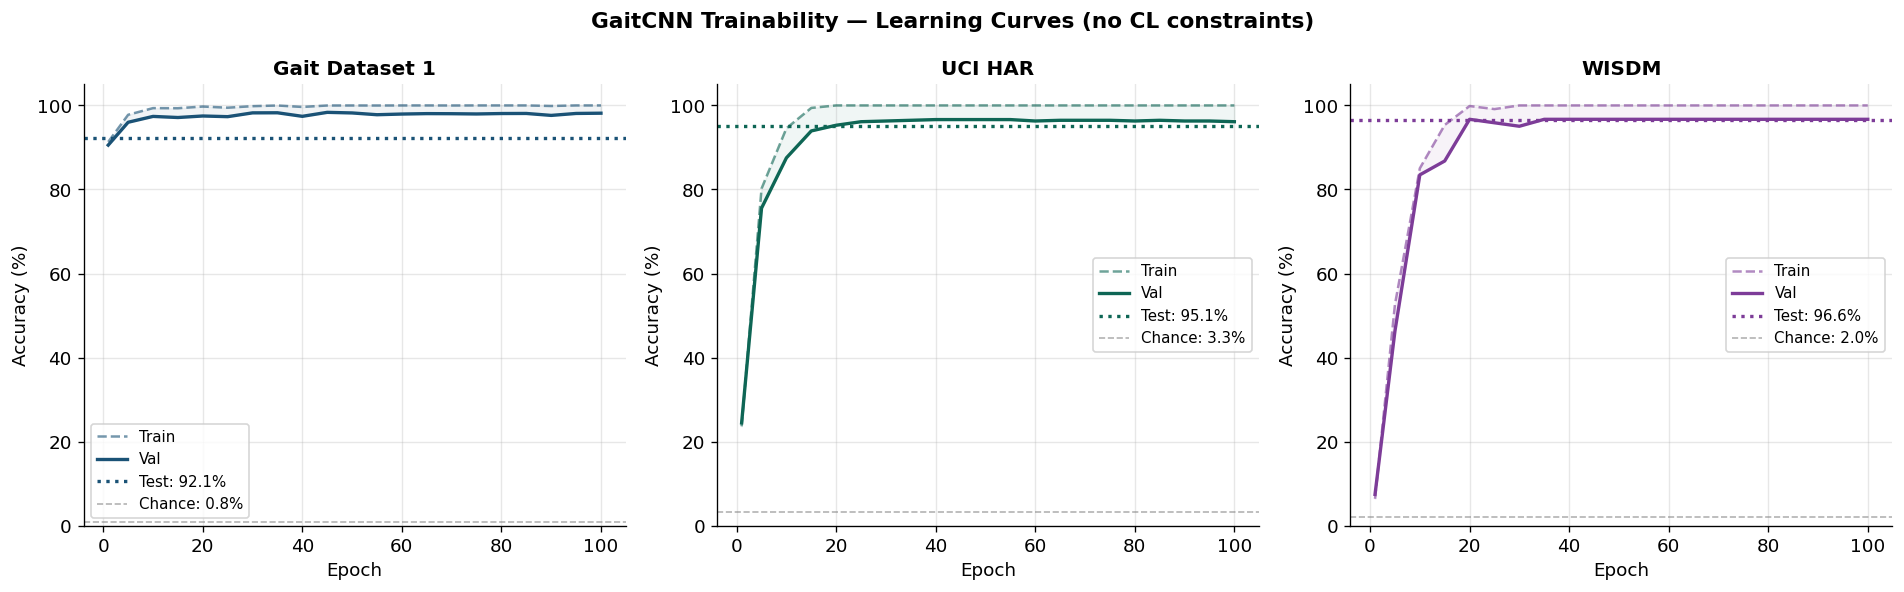

In [19]:
results = {
    'Gait Dataset 1': (hist_gait,  gait_n_classes,  DATASETS['Gait Dataset 1']['color']),
    'UCI HAR':         (hist_uci,   uci_n_classes,   DATASETS['UCI HAR']['color']),
    'WISDM':           (hist_wisdm, wisdm_n_classes, DATASETS['WISDM']['color']),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, (dname, (hist, n_cls, color)) in zip(axes, results.items()):
    chance = 100 / n_cls
    epochs = hist['epoch']
    ax.plot(epochs, hist['train_acc'], '--', color=color, alpha=0.6, lw=1.5, label='Train')
    ax.plot(epochs, hist['val_acc'],   '-',  color=color, lw=2.0,      label='Val')
    ax.axhline(hist['test_acc'], color=color, ls=':', lw=2.0,
               label=f'Test: {hist["test_acc"]:.1f}%')
    ax.axhline(chance, color='gray', ls='--', lw=1.0, alpha=0.6,
               label=f'Chance: {chance:.1f}%')
    ax.fill_between(epochs, hist['train_acc'], hist['val_acc'], alpha=0.06, color=color)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(dname, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 105)
    ax.legend(fontsize=9)

fig.suptitle('GaitCNN Trainability — Learning Curves (no CL constraints)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_trainability_curves.png', bbox_inches='tight')
plt.show()

## 8. Per-Subject Accuracy Distribution

How uniformly does the model learn across subjects?  
High variance means some subjects are much harder to identify than others.

--- Hardest 5 subjects for Gait Dataset 1 ---
  Subject 2: 0.0% accuracy
  Subject 113: 0.0% accuracy
  Subject 60: 10.5% accuracy
  Subject 3: 14.3% accuracy
  Subject 62: 31.7% accuracy

--- Hardest 5 subjects for UCI HAR ---
  Subject 18: 75.0% accuracy
  Subject 21: 84.2% accuracy
  Subject 28: 87.0% accuracy
  Subject 16: 87.5% accuracy
  Subject 2: 88.0% accuracy

--- Hardest 5 subjects for WISDM ---
  Subject 44: 50.0% accuracy
  Subject 40: 66.7% accuracy
  Subject 50: 75.0% accuracy
  Subject 47: 75.0% accuracy
  Subject 46: 75.0% accuracy



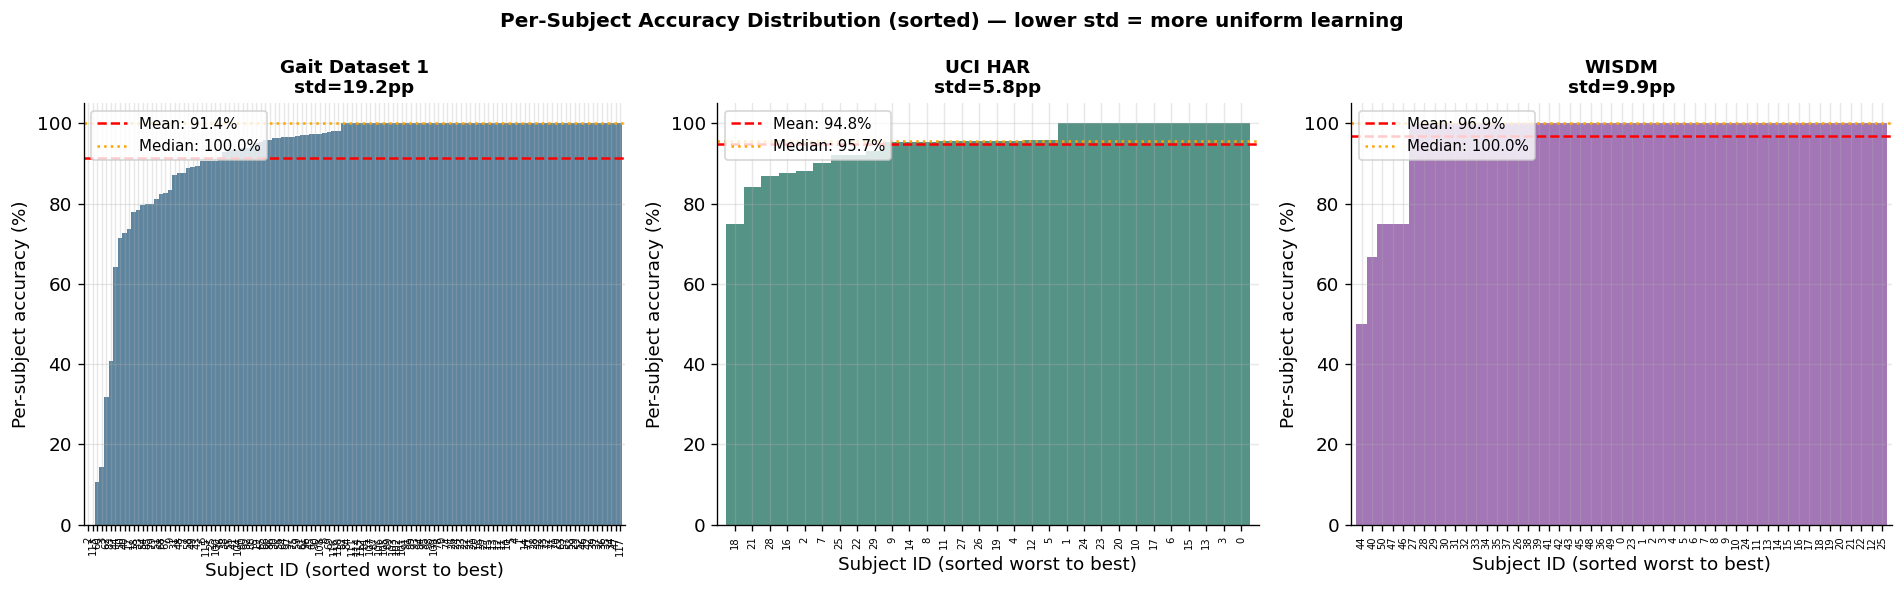

In [20]:
@torch.no_grad()
def per_class_accuracy(model, dataset, device):
    model.eval()
    loader   = DataLoader(dataset, batch_size=256, shuffle=False)
    all_pred, all_true = [], []
    for X_b, y_b in loader:
        all_pred.extend(model(X_b.to(device)).argmax(1).cpu().numpy())
        all_true.extend(y_b.numpy())
    all_pred = np.array(all_pred); all_true = np.array(all_true)
    classes  = np.sort(np.unique(all_true))
    per_cls  = [(all_pred[all_true == c] == c).mean() * 100 for c in classes]
    
    # CHANGE 1: Return both the classes and their accuracies
    return classes, np.array(per_cls)

# Unpack the two returned values for each dataset
gait_classes, gait_per_cls   = per_class_accuracy(model_gait,  gait_test,  DEVICE)
uci_classes, uci_per_cls     = per_class_accuracy(model_uci,   uci_test,   DEVICE)
wisdm_classes, wisdm_per_cls = per_class_accuracy(model_wisdm, wisdm_test, DEVICE)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (dname, classes, per_cls, color) in zip(axes, [
    ('Gait Dataset 1', gait_classes,  gait_per_cls,  DATASETS['Gait Dataset 1']['color']),
    ('UCI HAR',        uci_classes,   uci_per_cls,   DATASETS['UCI HAR']['color']),
    ('WISDM',          wisdm_classes, wisdm_per_cls, DATASETS['WISDM']['color']),
]):
    # CHANGE 2: Use argsort to get the sorting indices
    sort_idx = np.argsort(per_cls)
    sorted_cls = per_cls[sort_idx]       # The sorted accuracies (y-axis)
    sorted_labels = classes[sort_idx]    # The matched subject IDs (x-axis)
    
    # Plotting the bars
    x_pos = range(len(sorted_cls))
    ax.bar(x_pos, sorted_cls, color=color, alpha=0.7, width=1.0)
    
    # CHANGE 3: Set the actual subject IDs as x-axis labels
    ax.set_xticks(x_pos)
    # Rotating them 90 degrees and making them small so they don't overlap too much
    ax.set_xticklabels(sorted_labels, rotation=90, fontsize=6) 

    ax.axhline(np.mean(per_cls), color='red', ls='--', lw=1.5,
               label=f'Mean: {np.mean(per_cls):.1f}%')
    ax.axhline(np.median(per_cls), color='orange', ls=':', lw=1.5,
               label=f'Median: {np.median(per_cls):.1f}%')
    ax.set_xlabel('Subject ID (sorted worst to best)')
    ax.set_ylabel('Per-subject accuracy (%)')
    ax.set_title(f'{dname}\nstd={np.std(per_cls):.1f}pp', fontsize=11, fontweight='bold')
    ax.set_ylim(0, 105)
    # Give the x-axis a tiny bit of breathing room
    ax.set_xlim(-1, len(sorted_cls)) 
    ax.legend(fontsize=9)
    
    # CHANGE 4: Print the absolute hardest subjects directly to the console for easy reading
    print(f"--- Hardest 5 subjects for {dname} ---")
    for i in range(5):
        print(f"  Subject {sorted_labels[i]}: {sorted_cls[i]:.1f}% accuracy")
    print()

fig.suptitle('Per-Subject Accuracy Distribution (sorted) — lower std = more uniform learning',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_trainability_per_subject_labeled.png', bbox_inches='tight')
plt.show()

## 9. Final Summary

In [21]:
print('=' * 80)
print('TRAINABILITY SUMMARY — GaitCNN baseline (no CL)')
print('=' * 80)
print(f'  {"Dataset":<22} {"Subjects":>9} {"Win.size":>9} {"Train N":>9} '
      f'{"Test N":>9} {"Chance":>8} {"Test Acc":>10} {"Lift":>8} {"Std":>8}')
print('  ' + '─' * 79)

dataset_info = [
    ('Gait Dataset 1', gait_n_classes,  128, len(gait_train),  len(gait_test),
     hist_gait,  gait_per_cls),
    ('UCI HAR',        uci_n_classes,   128, len(uci_train),   len(uci_test),
     hist_uci,   uci_per_cls),
    ('WISDM',          wisdm_n_classes, 200, len(wisdm_train), len(wisdm_test),
     hist_wisdm, wisdm_per_cls),
]

for dname, n_cls, wsize, n_tr, n_te, hist, per_cls in dataset_info:
    chance = 100 / n_cls
    lift   = hist['test_acc'] - chance
    std    = np.std(per_cls)
    diff   = hist['train_acc'][-1] - hist['test_acc']
    print(f'  {dname:<22} {n_cls:>9} {wsize:>9} {n_tr:>9} '
          f'{n_te:>9} {chance:>7.1f}% {hist["test_acc"]:>9.1f}% '
          f'{lift:>+7.1f}pp {std:>7.1f}pp')

print()
print('  Notes:')
print('  - Lift = test accuracy above random guessing')
print('  - Std  = per-subject accuracy std (lower = more uniform)')
print()
print('  Train/Val/Test overfit check:')
for dname, n_cls, wsize, n_tr, n_te, hist, per_cls in dataset_info:
    gap = hist['train_acc'][-1] - hist['test_acc']
    flag = '⚠ overfit?' if gap > 15 else '✓ ok'
    print(f'  {dname:<22}  train={hist["train_acc"][-1]:.1f}%  '
          f'val_best={hist["best_val"]:.1f}%  test={hist["test_acc"]:.1f}%  '
          f'gap={gap:+.1f}pp  {flag}')
print()


TRAINABILITY SUMMARY — GaitCNN baseline (no CL)
  Dataset                 Subjects  Win.size   Train N    Test N   Chance   Test Acc     Lift      Std
  ───────────────────────────────────────────────────────────────────────────────
  Gait Dataset 1               118       128     28139      3740     0.8%      92.1%   +91.3pp    19.2pp
  UCI HAR                       30       128      3364       715     3.3%      95.1%   +91.8pp     5.8pp
  WISDM                         51       200       688       175     2.0%      96.6%   +94.6pp     9.9pp

  Notes:
  - Lift = test accuracy above random guessing
  - Std  = per-subject accuracy std (lower = more uniform)

  Train/Val/Test overfit check:
  Gait Dataset 1          train=100.0%  val_best=98.3%  test=92.1%  gap=+7.9pp  ✓ ok
  UCI HAR                 train=100.0%  val_best=96.6%  test=95.1%  gap=+4.9pp  ✓ ok
  WISDM                   train=100.0%  val_best=96.7%  test=96.6%  gap=+3.4pp  ✓ ok

